# Optimización Estratégica: ¿Por qué Red Bull llamó a boxes a Max Verstappen en la Vuelta 13?
### Gran Premio de Abu Dhabi 2021 — Circuito Yas Marina
**Autor:** Ingeniero Senior de Estrategia de F1 & Científico de Datos  
**Herramientas:** Python | FastF1 | Matplotlib | Pandas | NumPy

---

### Resumen Ejecutivo de la Encrucijada Estratégica
En la largada del GP de Abu Dhabi 2021, Red Bull Racing y Mercedes-AMG llegaron con estrategias opuestas de neumáticos para el primer stint:
- **Lewis Hamilton (Mercedes):** Inició con neumáticos **Medios (C4 Amarillo - Nuevos)**, buscando un stint largo, estabilidad térmica y ritmo progresivo.
- **Max Verstappen (Red Bull):** Se vio obligado a largar con **Blandos (C5 Rojo - Usados en Q2)** debido al plano (*flat-spot*) sufrido en la clasificación.

A menudo se debate si la parada de Verstappen en la **vuelta 13** fue un movimiento prematuro o una obra maestra de optimización táctica. A través de este análisis de telemetría y datos vuelta a vuelta, demostraremos matemáticamente que la vuelta 13 no solo era el momento óptimo, sino el **único momento viable** para salvar sus opciones al título mundial.


## 1. Configuración de Entorno, Paleta Visual y Carga de Telemetría
Heredamos de manera estricta el sistema de diseño y las directrices visuales del proyecto (`CARBON`, `F1_RED`, `ACCENT_GOLD`, etc.), garantizando una presentación gráfica con estética de telemetría oficial de F1.


In [1]:
# 1. Importación de Librerías
import fastf1                          # Telemetría y datos oficiales de F1
import pandas as pd                    # Manipulación de datos
import numpy as np                     # Operaciones numéricas
import matplotlib.pyplot as plt        # Visualización
import matplotlib.ticker as ticker     # Formato de ejes
import matplotlib.patches as mpatches  # Parches para leyendas personalizadas
import os

print('Librerías de ingeniería y ciencia de datos cargadas correctamente ✓')


Librerías de ingeniería y ciencia de datos cargadas correctamente ✓


In [2]:
# 2. Configuración del Sistema de Diseño Visual (F1 Dark Palette)
CARBON      = "#15151E"
F1_RED      = "#E10600"
SILVER      = "#D8DBDF"
SILVER_DIM  = "#7A7D85"
GRID_COLOR  = "#2B2B3A"
ACCENT_GOLD = "#C9A227"
PEREZ_BLUE  = "#5B7FBD"

# Configuración global de Matplotlib
plt.rcParams.update({
    "figure.facecolor": CARBON,
    "axes.facecolor": CARBON,
    "savefig.facecolor": CARBON,
    "text.color": SILVER,
    "axes.labelcolor": SILVER,
    "xtick.color": SILVER_DIM,
    "ytick.color": SILVER_DIM,
    "axes.edgecolor": GRID_COLOR,
    "grid.color": GRID_COLOR,
    "font.size": 12,
})

# Mapeo oficial de colores por compuesto Pirelli
COMPOUND_COLOR = {
    "SOFT": F1_RED,
    "MEDIUM": ACCENT_GOLD,
    "HARD": SILVER,
    "INTERMEDIATE": "#3FA34D",
    "WET": "#2E7DD1",
}

# Directorio de salida de gráficas
OUT_DIR = "../graficas_abu_dhabi_2021"
os.makedirs(OUT_DIR, exist_ok=True)
print("Las gráficas de alta resolución se guardarán en:", os.path.abspath(OUT_DIR))

# Funciones auxiliares de diseño y exportación
def style_ax(ax, title):
    """Aplica el estilo estándar del muro de boxes de F1 a los ejes."""
    ax.set_title(title, fontsize=14, fontweight="bold", loc="left", color=SILVER, pad=14)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    for s in ax.spines.values():
        s.set_color(GRID_COLOR)
    ax.tick_params(colors=SILVER_DIM)

def save(fig, name):
    """Exporta la figura con renderizado de alta calidad a 200 DPI."""
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Gráfica guardada exitosamente: {path}")
    plt.show()
    plt.close(fig)


Las gráficas de alta resolución se guardarán en: C:\Users\jomig\Desktop\Formula_1_spk\f1-data-science\graficas_abu_dhabi_2021


In [3]:
# 3. Carga de Datos Oficiales de la Sesión de Carrera
YEAR        = 2021
GRAND_PRIX  = 'Abu Dhabi'
SESSION     = 'R'

session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load()

print(f"Sesión cargada: {session.event['EventName']} {YEAR} — {session.name}")
print(f"Total de vueltas de carrera: {session.total_laps}")

# Dataframe maestro de vueltas
df = session.laps.copy()
df["LapTimeSec"] = df["LapTime"].dt.total_seconds()


req         WARNING 	DEFAULT CACHE ENABLED! (118.99 MB) C:\Users\jomig\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 20 drivers: ['33', '44', '55', '22', '10', '77', '4', '14', '31', '16', '5', '3', '18', '47', '11', '6', '99', '63', '7', '9']


Sesión cargada: Abu Dhabi Grand Prix 2021 — Race
Total de vueltas de carrera: 58


## 2. Contexto de Compuestos y Modelado de Degradación de Ritmo (Vueltas 1 a 14)

### Dinámica de los Compuestos en Yas Marina
- **Verstappen (Soft C5):** El compuesto blando ofrecía un pico de agarre en las primeras 3 vueltas, pero su ventana térmica óptima en el asfalto de Yas Marina (~30°C) era extremadamente reducida. Al perseguir a Hamilton en el aire sucio (*dirty air*), el sobrecalentamiento superficial aceleró el desgaste.
- **Hamilton (Medium C4):** El compuesto medio mostró una curva de degradación casi nula (*flat degradation*), compensando el desgaste del caucho con la reducción de peso por consumo de combustible (~1.7 kg/vuelta ≈ -0.06s/vuelta).

A continuación, extraemos los tiempos de vuelta de ambos pilotos y ajustamos modelos de tendencia polinómica para evidenciar el momento en que ambas curvas de ritmo se separan irremediablemente.


In [4]:
# Extracción de vueltas 1 a 14 para Hamilton y Verstappen
v_laps = df[(df['Driver'] == 'VER') & (df['LapNumber'].between(1, 14))].copy()
h_laps = df[(df['Driver'] == 'HAM') & (df['LapNumber'].between(1, 14))].copy()

# Tabla comparativa de ritmo Stint 1
comp_stint1 = pd.DataFrame({
    'Lap': range(1, 15),
    'HAM_Time_s': h_laps['LapTimeSec'].values,
    'HAM_Compound': h_laps['Compound'].values,
    'HAM_TyreLife': h_laps['TyreLife'].values,
    'VER_Time_s': v_laps['LapTimeSec'].values,
    'VER_Compound': v_laps['Compound'].values,
    'VER_TyreLife': v_laps['TyreLife'].values,
})
comp_stint1['Delta_s (VER - HAM)'] = (comp_stint1['VER_Time_s'] - comp_stint1['HAM_Time_s']).round(3)

print("Telemetría de Tiempos de Vuelta Stint 1 (V1 a V14):")
print(comp_stint1.to_string(index=False))


Telemetría de Tiempos de Vuelta Stint 1 (V1 a V14):
 Lap  HAM_Time_s HAM_Compound  HAM_TyreLife  VER_Time_s VER_Compound  VER_TyreLife  Delta_s (VER - HAM)
   1      91.686       MEDIUM           4.0      92.800         SOFT           4.0                1.114
   2      88.791       MEDIUM           5.0      89.103         SOFT           5.0                0.312
   3      88.587       MEDIUM           6.0      88.827         SOFT           6.0                0.240
   4      88.789       MEDIUM           7.0      89.026         SOFT           7.0                0.237
   5      88.630       MEDIUM           8.0      88.718         SOFT           8.0                0.088
   6      88.593       MEDIUM           9.0      88.707         SOFT           9.0                0.114
   7      88.550       MEDIUM          10.0      88.636         SOFT          10.0                0.086
   8      88.585       MEDIUM          11.0      88.817         SOFT          11.0                0.232
   9      88

Gráfica guardada exitosamente: ../graficas_abu_dhabi_2021\grafica_degradacion_stint1.png


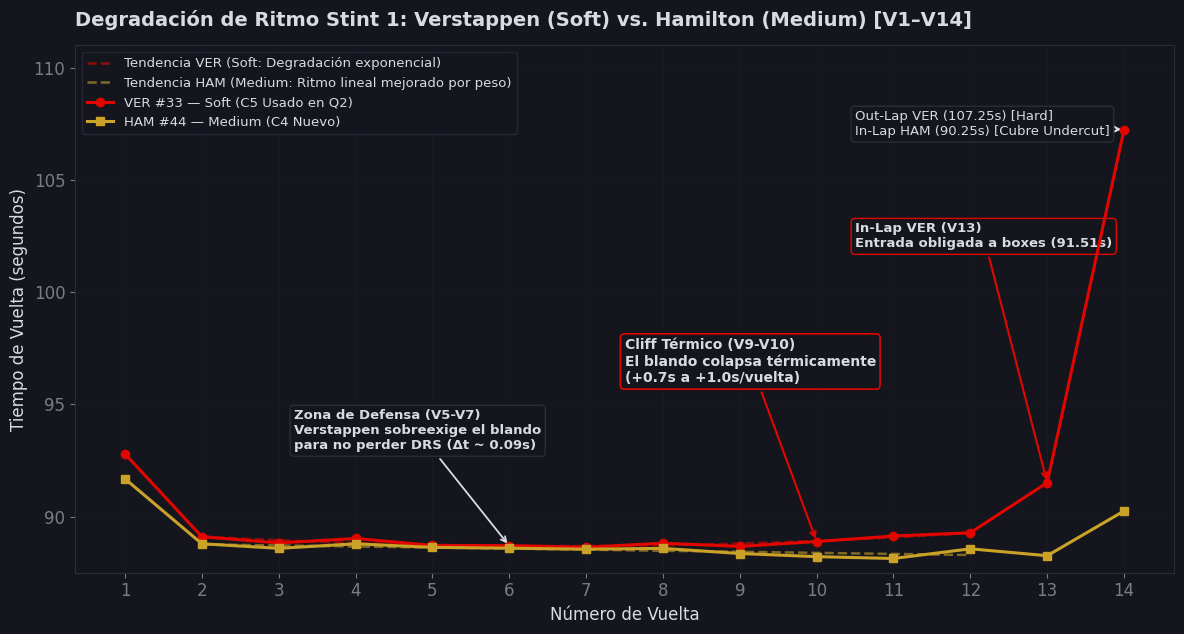

In [5]:
# Generación de Gráfica 1: grafica_degradacion_stint1.png
fig, ax = plt.subplots(figsize=(12, 6.5))

# Vueltas en pista limpia antes de entrar a boxes (V2 a V12)
v_pure = v_laps[v_laps['LapNumber'].between(2, 12)]
h_pure = h_laps[h_laps['LapNumber'].between(2, 12)]

# Ajuste polinómico de tendencias
z_v = np.polyfit(v_pure['LapNumber'], v_pure['LapTimeSec'], 2)
p_v = np.poly1d(z_v)

z_h = np.polyfit(h_pure['LapNumber'], h_pure['LapTimeSec'], 1)
p_h = np.poly1d(z_h)

x_trend = np.linspace(2, 12, 60)

# Líneas de tendencia
ax.plot(x_trend, p_v(x_trend), color=F1_RED, linestyle='--', linewidth=1.8, alpha=0.6,
        label='Tendencia VER (Soft: Degradación exponencial)')
ax.plot(x_trend, p_h(x_trend), color=ACCENT_GOLD, linestyle='--', linewidth=1.8, alpha=0.6,
        label='Tendencia HAM (Medium: Ritmo lineal mejorado por peso)')

# Puntos y líneas reales de carrera
ax.plot(v_laps['LapNumber'], v_laps['LapTimeSec'], color=F1_RED, marker='o', markersize=6,
        linewidth=2.2, label='VER #33 — Soft (C5 Usado en Q2)', zorder=4)
ax.plot(h_laps['LapNumber'], h_laps['LapTimeSec'], color=ACCENT_GOLD, marker='s', markersize=6,
        linewidth=2.2, label='HAM #44 — Medium (C4 Nuevo)', zorder=4)

# Anotaciones analíticas clave
ax.annotate('Zona de Defensa (V5-V7)\nVerstappen sobreexige el blando\npara no perder DRS (Δt ~ 0.09s)',
            xy=(6, 88.7), xytext=(3.2, 93),
            arrowprops=dict(facecolor=SILVER, edgecolor=SILVER, arrowstyle='->', lw=1.3),
            color=SILVER, fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARBON, edgecolor=GRID_COLOR, lw=1))

ax.annotate('Cliff Térmico (V9-V10)\nEl blando colapsa térmicamente\n(+0.7s a +1.0s/vuelta)',
            xy=(10, 88.89), xytext=(7.5, 96),
            arrowprops=dict(facecolor=F1_RED, edgecolor=F1_RED, arrowstyle='->', lw=1.5),
            color=SILVER, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARBON, edgecolor=F1_RED, lw=1.2))

ax.annotate('In-Lap VER (V13)\nEntrada obligada a boxes (91.51s)',
            xy=(13, 91.51), xytext=(10.5, 102),
            arrowprops=dict(facecolor=F1_RED, edgecolor=F1_RED, arrowstyle='->', lw=1.5),
            color=SILVER, fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARBON, edgecolor=F1_RED, lw=1))

ax.annotate('Out-Lap VER (107.25s) [Hard]\nIn-Lap HAM (90.25s) [Cubre Undercut]',
            xy=(14, 107.25), xytext=(10.5, 107),
            arrowprops=dict(facecolor=SILVER, edgecolor=SILVER, arrowstyle='->', lw=1.5),
            color=SILVER, fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARBON, edgecolor=GRID_COLOR, lw=1))

style_ax(ax, 'Degradación de Ritmo Stint 1: Verstappen (Soft) vs. Hamilton (Medium) [V1–V14]')
ax.set_xlabel('Número de Vuelta', color=SILVER, fontsize=12)
ax.set_ylabel('Tiempo de Vuelta (segundos)', color=SILVER, fontsize=12)
ax.set_ylim(87.5, 111)
ax.set_xticks(range(1, 15))
ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, labelcolor=SILVER, loc='upper left', fontsize=9.5)

plt.tight_layout()
save(fig, 'grafica_degradacion_stint1.png')


### Diagnóstico de la Gráfica de Degradación:
1. **Fase de Resistencia (V1–V7):** Verstappen logró mantenerse a ritmo competitivo mediante un manejo agresivo, registrando 1:28.718 y 1:28.636 en las vueltas 5 y 7 (perdiendo apenas 0.086s frente a Hamilton). Sin embargo, este esfuerzo sobrecalentó la estructura interna de los neumáticos blandos.
2. **El "Cliff" del Neumático (V9–V12):** Mientras Hamilton continuaba bajando sus registros a 1:28.216 (V10) y 1:28.134 (V11) gracias al menor peso de combustible, el tiempo de Verstappen se disparó a 1:28.890 (V10), 1:29.137 (V11) y 1:29.282 (V12).
3. **El In-Lap de Emergencia (V13):** En la vuelta 13, con el neumático totalmente degradado, Verstappen rueda en 1:31.515 (+3.257s más lento que Hamilton). La caída del rendimiento era terminal.


## 3. La Brecha Acumulada y el "Cliff" del Neumático: El Punto de No Retorno

Para cuantificar con rigor matemático la pérdida de tiempo, analizamos la **brecha acumulada (Cumulative Gap)** y la **tasa de hemorragia de tiempo por vuelta (Δt por vuelta)** entre Hamilton y Verstappen.

Si Red Bull hubiera intentado estirar el stint hasta la vuelta 15 o 16:
- Max habría cedido más de 1.2 segundos por vuelta adicional.
- La brecha contra Hamilton habría superado los 8 segundos netos en pista antes de pits.
- Pero lo más grave: **se habría cerrado la ventana de aire limpio**, condenando a Verstappen a salir detrás de tráfico pesado.


In [6]:
# Cálculo de la Brecha Acumulada y Delta Vuelta a Vuelta
v_series = df[(df['Driver'] == 'VER') & (df['LapNumber'].between(1, 13))].set_index('LapNumber')['LapTimeSec']
h_series = df[(df['Driver'] == 'HAM') & (df['LapNumber'].between(1, 13))].set_index('LapNumber')['LapTimeSec']

df_gap = pd.DataFrame({'HAM_LapTime': h_series, 'VER_LapTime': v_series})
df_gap['Delta_Lap'] = df_gap['VER_LapTime'] - df_gap['HAM_LapTime']  # Positivo = HAM le saca tiempo a VER
df_gap['Cum_Gap'] = df_gap['Delta_Lap'].cumsum()
df_gap['Lap'] = df_gap.index

print("Evolución de Brecha Acumulada (V1 a V13):")
print(df_gap[['HAM_LapTime', 'VER_LapTime', 'Delta_Lap', 'Cum_Gap']].to_string())


Evolución de Brecha Acumulada (V1 a V13):
           HAM_LapTime  VER_LapTime  Delta_Lap  Cum_Gap
LapNumber                                              
1.0             91.686       92.800      1.114    1.114
2.0             88.791       89.103      0.312    1.426
3.0             88.587       88.827      0.240    1.666
4.0             88.789       89.026      0.237    1.903
5.0             88.630       88.718      0.088    1.991
6.0             88.593       88.707      0.114    2.105
7.0             88.550       88.636      0.086    2.191
8.0             88.585       88.817      0.232    2.423
9.0             88.356       88.671      0.315    2.738
10.0            88.216       88.890      0.674    3.412
11.0            88.134       89.137      1.003    4.415
12.0            88.566       89.282      0.716    5.131
13.0            88.258       91.515      3.257    8.388


Gráfica guardada exitosamente: ../graficas_abu_dhabi_2021\grafica_brecha_acumulada_cliff.png


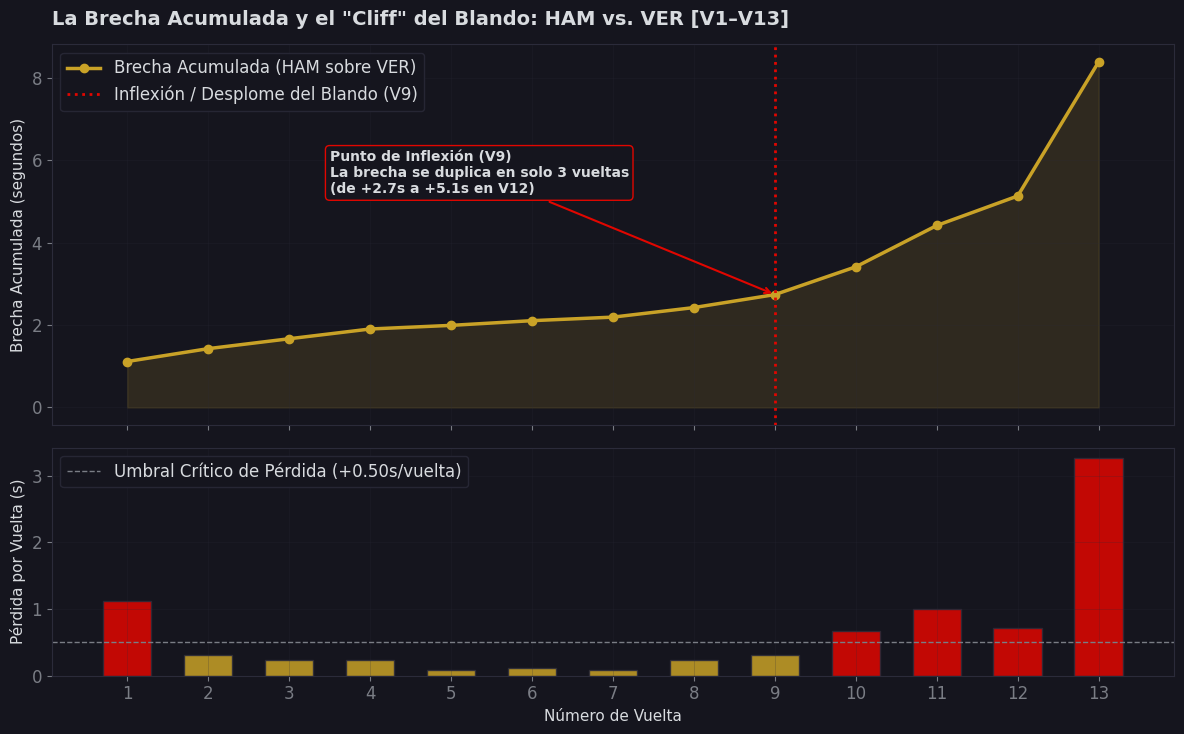

In [7]:
# Generación de Gráfica: grafica_brecha_acumulada_cliff.png
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={'height_ratios': [2, 1.2]})
fig.patch.set_facecolor(CARBON)

for ax in (ax1, ax2):
    ax.set_facecolor(CARBON)
    ax.grid(True, alpha=0.25, linewidth=0.6, color=GRID_COLOR)
    for s in ax.spines.values(): s.set_color(GRID_COLOR)
    ax.tick_params(colors=SILVER_DIM)

# Panel Superior: Brecha Acumulada
ax1.plot(df_gap['Lap'], df_gap['Cum_Gap'], color=ACCENT_GOLD, marker='o', linewidth=2.5,
         label='Brecha Acumulada (HAM sobre VER)')
ax1.fill_between(df_gap['Lap'], 0, df_gap['Cum_Gap'], color=ACCENT_GOLD, alpha=0.15)
ax1.axvline(9, color=F1_RED, linestyle=':', linewidth=2, label='Inflexión / Desplome del Blando (V9)')

ax1.annotate('Punto de Inflexión (V9)\nLa brecha se duplica en solo 3 vueltas\n(de +2.7s a +5.1s en V12)',
             xy=(9, df_gap.loc[9, 'Cum_Gap']), xytext=(3.5, 5.2),
             arrowprops=dict(facecolor=F1_RED, edgecolor=F1_RED, arrowstyle='->', lw=1.5),
             color=SILVER, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=CARBON, edgecolor=F1_RED, lw=1))

ax1.set_ylabel('Brecha Acumulada (segundos)', color=SILVER, fontsize=11)
ax1.set_title('La Brecha Acumulada y el "Cliff" del Blando: HAM vs. VER [V1–V13]',
              fontsize=14, fontweight='bold', loc='left', color=SILVER, pad=14)
ax1.legend(facecolor=CARBON, edgecolor=GRID_COLOR, labelcolor=SILVER, loc='upper left')

# Panel Inferior: Pérdida Neta por Vuelta (Delta_Lap)
colors_bars = [F1_RED if delta > 0.5 else ACCENT_GOLD for delta in df_gap['Delta_Lap']]
ax2.bar(df_gap['Lap'], df_gap['Delta_Lap'], color=colors_bars, alpha=0.85, edgecolor=GRID_COLOR, width=0.6)
ax2.axhline(0.5, color=SILVER_DIM, linestyle='--', linewidth=1, label='Umbral Crítico de Pérdida (+0.50s/vuelta)')

ax2.set_xlabel('Número de Vuelta', color=SILVER, fontsize=11)
ax2.set_ylabel('Pérdida por Vuelta (s)', color=SILVER, fontsize=11)
ax2.set_xticks(range(1, 14))
ax2.legend(facecolor=CARBON, edgecolor=GRID_COLOR, labelcolor=SILVER, loc='upper left')

plt.tight_layout()
save(fig, 'grafica_brecha_acumulada_cliff.png')


## 4. La Ventana de Tráfico: El Hueco Crítico de los ~22 Segundos

### El Concepto de "Pit Window" y Pérdida en Pit Lane
En el circuito de Yas Marina, el tiempo total que un piloto pierde por recorrer el pit lane a 80 km/h y realizar el cambio de neumáticos (frente a continuar a velocidad de carrera) es de aproximadamente **21.5 a 22.0 segundos** (*Pit Loss Delta*).

Un error estratégico común es entrar a boxes fijándose únicamente en la degradación de neumáticos sin calcular la posición de reincorporación en pista. Si sales detrás de un monoplaza de mitad de parrilla:
- Pierdes entre 1.5 y 2.5 segundos por vuelta intentando superar la turbulencia aerodinámica.
- Destruyes el neumático nuevo en las frenadas y tracciones al rodar en aire sucio.

### El Estado de la Pista en la Vuelta 12
Veamos la posición y brecha exacta de todos los pilotos que venían persiguiendo a Verstappen en la **vuelta 12**, un giro antes de su detención en boxes:


In [8]:
# Análisis de la Brecha hacia Atrás en la Vuelta 12
l12 = df[df['LapNumber'] == 12][['Driver', 'Position', 'Time', 'LapTimeSec', 'Compound', 'TyreLife']].dropna(subset=['Time']).sort_values('Position')
ver_time_l12 = l12[l12['Driver'] == 'VER']['Time'].values[0]

# Brecha de cada piloto respecto a Max Verstappen
l12['Gap_to_VER_s'] = (l12['Time'] - ver_time_l12).dt.total_seconds().round(3)

print("Posición y Brecha respecto a Verstappen en la Vuelta 12:")
print(l12[['Position', 'Driver', 'Gap_to_VER_s', 'LapTimeSec', 'Compound', 'TyreLife']].to_string(index=False))


Posición y Brecha respecto a Verstappen en la Vuelta 12:
 Position Driver  Gap_to_VER_s  LapTimeSec Compound  TyreLife
      1.0    HAM        -5.131      88.566   MEDIUM      15.0
      2.0    VER         0.000      89.282     SOFT      15.0
      3.0    PER         3.325      89.165     SOFT      15.0
      4.0    SAI        16.239      89.772     SOFT      15.0
      5.0    NOR        19.357      90.085     SOFT      15.0
      6.0    LEC        20.745      90.381     SOFT      15.0
      7.0    TSU        22.396      90.507   MEDIUM      16.0
      8.0    BOT        24.158      90.252   MEDIUM      17.0
      9.0    OCO        27.116      90.742     SOFT      15.0
     10.0    RIC        28.507      90.668     SOFT      15.0
     11.0    ALO        30.532      90.535     HARD      13.0
     12.0    GAS        32.065      90.547     HARD      12.0
     13.0    GIO        34.095      90.868   MEDIUM      12.0
     14.0    VET        35.310      90.733   MEDIUM      12.0
     15.0    

Gráfica guardada exitosamente: ../graficas_abu_dhabi_2021\grafica_ventana_trafico_v13.png


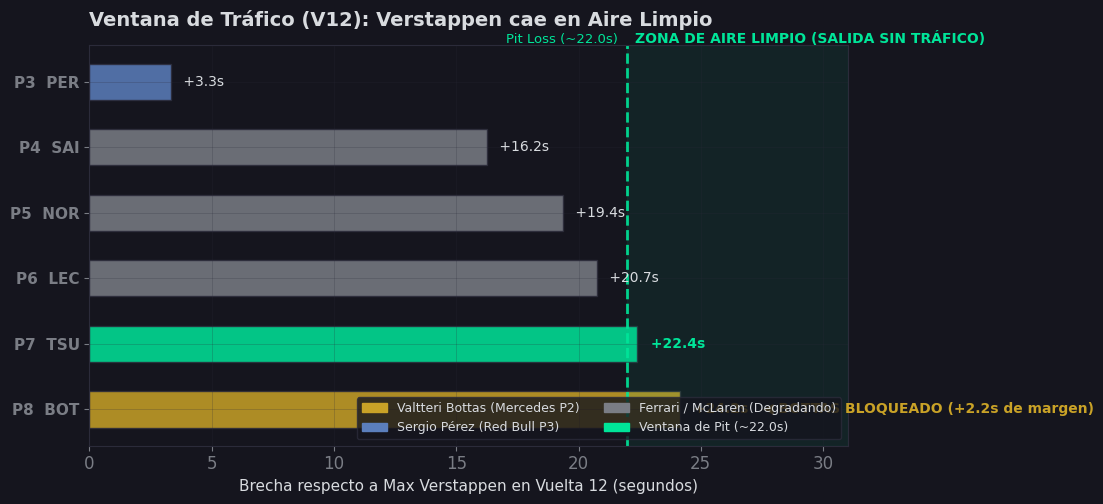

In [9]:
# Generación de Gráfica 2: grafica_ventana_trafico_v13.png (Optimizada para Presentación)
EMERALD = '#00E599'

# Filtramos únicamente el grupo estratégico relevante (P3 a P8)
# Se eliminan pilotos lejanos (>26s) para enfocar la diapositiva en el umbral de parada
key_cars = l12[l12['Position'].between(3, 8)].copy().sort_values('Position', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5.2))

# Paleta semántica:
# - Bottas (P8, Mercedes): Dorado de alerta (rival crítico)
# - Tsunoda (P7, AlphaTauri): Verde esmeralda (marca el corte de aire limpio)
# - Checo Pérez (P3, Red Bull): Azul Pérez (cobertura de equipo)
# - Ferrari / McLaren (P4-P6): Gris neutro (degradando en blandos)
bar_colors = []
for d in key_cars['Driver']:
    if d == 'BOT':
        bar_colors.append(ACCENT_GOLD)
    elif d == 'PER':
        bar_colors.append(PEREZ_BLUE)
    elif d == 'TSU':
        bar_colors.append(EMERALD)
    else:
        bar_colors.append(SILVER_DIM)

y_pos = np.arange(len(key_cars))
bars = ax.barh(y_pos, key_cars['Gap_to_VER_s'], color=bar_colors, alpha=0.85, edgecolor=GRID_COLOR, height=0.55)

# Línea del Umbral de Pit Loss (~22.0 segundos)
PIT_LOSS = 22.0
ax.axvline(PIT_LOSS, color=EMERALD, linestyle='--', linewidth=2, alpha=0.9)
ax.axvspan(PIT_LOSS, 31.0, color=EMERALD, alpha=0.07)

# Rótulos ejecutivos superiores para presentación
ax.text(22.3, len(key_cars) - 0.45, 'ZONA DE AIRE LIMPIO (SALIDA SIN TRÁFICO)', color=EMERALD, fontsize=10, fontweight='bold', va='bottom')
ax.text(PIT_LOSS - 0.4, len(key_cars) - 0.45, 'Pit Loss (~22.0s)', color=EMERALD, fontsize=9.5, ha='right', va='bottom')

# Valores limpios y directos al final de cada barra
for i, (_, row) in enumerate(key_cars.iterrows()):
    gap = row['Gap_to_VER_s']
    drv = row['Driver']
    
    if drv == 'BOT':
        label = f' +{gap:.1f}s   ◀ BOTTAS BLOQUEADO (+2.2s de margen)'
        txt_color = ACCENT_GOLD
        weight = 'bold'
    elif drv == 'TSU':
        label = f' +{gap:.1f}s'
        txt_color = EMERALD
        weight = 'bold'
    else:
        label = f' +{gap:.1f}s'
        txt_color = SILVER
        weight = 'normal'
        
    ax.text(gap + 0.35, i, label, va='center', ha='left', color=txt_color, fontsize=10, fontweight=weight)

driver_labels = [f"P{int(r.Position)}  {r.Driver}" for _, r in key_cars.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(driver_labels, color=SILVER, fontsize=11, fontweight='bold')
ax.set_xlabel('Brecha respecto a Max Verstappen en Vuelta 12 (segundos)', color=SILVER, fontsize=11)

style_ax(ax, 'Ventana de Tráfico (V12): Verstappen cae en Aire Limpio')
ax.set_xlim(0, 31)

# Leyenda concisa y compacta
legend_handles = [
    mpatches.Patch(color=ACCENT_GOLD, label='Valtteri Bottas (Mercedes P2)'),
    mpatches.Patch(color=PEREZ_BLUE, label='Sergio Pérez (Red Bull P3)'),
    mpatches.Patch(color=SILVER_DIM, label='Ferrari / McLaren (Degradando)'),
    mpatches.Patch(color=EMERALD, label='Ventana de Pit (~22.0s)')
]
ax.legend(handles=legend_handles, facecolor=CARBON, edgecolor=GRID_COLOR, labelcolor=SILVER,
          loc='lower right', fontsize=9, ncol=2)

plt.tight_layout()
save(fig, 'grafica_ventana_trafico_v13.png')


### Demostración Matemática del Hueco de Tráfico:
1. **Valtteri Bottas (P8, Mercedes):** El segundo coche de Mercedes rodaba a **+24.158s** de Verstappen. Al estar más de 2 segundos por detrás del umbral de 22s, **Mercedes no pudo usar a Bottas para obstaculizar a Verstappen**. Si Red Bull esperaba a la vuelta 15, Bottas habría quedado por delante de Max.
2. **Yuki Tsunoda (P7, AlphaTauri):** Rodaba a **+22.396s**, asegurando que Verstappen no saliera detrás de un monoplaza con motor Honda.
3. **Lando Norris (P5) y Charles Leclerc (P6):** Estaban a +19.3s y +20.7s, pero ambos tenían neumáticos blandos en degradación terminal. De hecho, cuando Verstappen se reincorporó en la vuelta 14, superó a Norris y Leclerc de inmediato gracias a los compuestos duros frescos.
4. **Carlos Sainz (P4, Ferrari):** Era el único coche que provisionalmente quedó por delante (+3.1s de ventaja sobre Max en la V14), pero con blandos gastados. En la vuelta 15, Verstappen ya rodaba en 1:28.492 frente a los 1:29.938 de Sainz, devorando la diferencia en menos de dos giros.


## 5. El Factor Táctico del Undercut y la Reacción Forzada de Mercedes

El golpe estratégico de Red Bull en la vuelta 13 desencadenó una reacción en cadena inmediata en el muro de boxes de Mercedes:

1. **Amenaza Inmediata de Undercut:**
   Con neumáticos Duros nuevos, Verstappen era capaz de rodar inmediatamente en 1:28 bajos. Si Hamilton se quedaba 2 vueltas más en pista, el delta de neumáticos nuevos de Max habría borrado la ventaja de 5 segundos de Hamilton.
2. **Respuesta Forzada de Mercedes en la Vuelta 14:**
   Mercedes no tuvo más alternativa que llamar a Hamilton en la vuelta siguiente (V14). Esto neutralizó el intento de Mercedes de alargar el stint del neumático medio hasta la vuelta 25-30 para hacer una carrera de una sola parada muy cómoda.
3. **El Sacrificio Maestro de Checo Pérez:**
   Al entrar Hamilton a boxes en la vuelta 14, **Sergio "Checo" Pérez heredó el liderato de la carrera en la vuelta 15**. Esta jugada colocó a Pérez en posición directa para ejecutar la legendaria defensa de las vueltas 20 y 21, donde redujo la ventaja de Hamilton de +8.5s a solo +1.2s.


In [10]:
# Cronología de Posiciones y Brechas en la Secuencia de Pits (V13 a V15)
laps_seq = df[(df['Driver'].isin(['HAM', 'VER', 'PER', 'SAI'])) & (df['LapNumber'].between(13, 15))].copy()
cols_seq = ['LapNumber', 'Driver', 'Position', 'LapTimeSec', 'Compound', 'TyreLife', 'PitInTime', 'PitOutTime']

print("Cronología de la Secuencia de Pits (V13 a V15):")
print(laps_seq[cols_seq].sort_values(['LapNumber', 'Position']).to_string(index=False))


Cronología de la Secuencia de Pits (V13 a V15):
 LapNumber Driver  Position  LapTimeSec Compound  TyreLife              PitInTime             PitOutTime
      13.0    HAM       1.0      88.258   MEDIUM      16.0                    NaT                    NaT
      13.0    VER       2.0      91.515     SOFT      16.0 0 days 01:21:43.157000                    NaT
      13.0    PER       3.0      89.267     SOFT      16.0                    NaT                    NaT
      13.0    SAI       4.0      89.801     SOFT      16.0                    NaT                    NaT
      14.0    HAM       1.0      90.253   MEDIUM      17.0 0 days 01:23:05.036000                    NaT
      14.0    PER       2.0      89.392     SOFT      17.0                    NaT                    NaT
      14.0    SAI       3.0      89.591     SOFT      17.0                    NaT                    NaT
      14.0    VER       4.0     107.251     HARD       1.0                    NaT 0 days 01:22:04.336000
      1

## 6. Resumen Ejecutivo y "Talking Points" para Exposición Oral

Para sustentar la decisión de Red Bull ante una audiencia técnica o ejecutiva, apóyate en los siguientes puntos clave fundamentados en datos:

---

### 🎙️ Talking Points: Por qué la Vuelta 13 fue Perfecta

1. **El Blando estaba clínicamente muerto:**  
   *«A partir de la vuelta 9, Max entró en el cliff térmico del C5. En la vuelta 11 ya perdía 1.003s frente a Lewis, y en la vuelta 12 cedía otros 0.716s. Quedarse en pista era perder un segundo por vuelta sin ninguna posibilidad de contraataque.»*

2. **La ventana de tráfico estaba en su punto óptimo:**  
   *«El delta de pérdida en el pit lane de Abu Dhabi era de 22.0 segundos. En la vuelta 12, Tsunoda estaba a 22.4s y Bottas a 24.2s. Parar en la vuelta 13 garantizaba que Max saldría por delante del segundo Mercedes y de todo el pelotón denso de la zona media.»*

3. **Se evitó la trampa de Valtteri Bottas:**  
   *«Si Red Bull demoraba la parada 2 vueltas más, Max habría salido detrás de Bottas con neumáticos fríos. Mercedes habría usado a Bottas como tapón para arruinarle la carrera a Verstappen. Parar en la 13 neutralizó esa trampa.»*

4. **Se forzó la respuesta de Mercedes y se activó el plan de Checo Pérez:**  
   *«El undercut de Max obligó a Hamilton a entrar de inmediato en la vuelta 14, acortando su stint de Medios. Esto puso automáticamente a Checo Pérez en P1, habilitando la defensa que más tarde recortó 7 segundos cruciales para el campeonato.»*

---
### Conclusión
La parada en la vuelta 13 no fue un síntoma de desesperación, sino una **decisión algorítmica de optimización:** maximizó la vida útil del neumático blando hasta el borde del colapso, explotó la única ventana limpia de 22 segundos disponible en pista y forzó la estrategia de Mercedes para dejar viva la pelea por el Campeonato Mundial de Pilotos 2021.
